<a href="https://colab.research.google.com/github/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/blob/main/energy_clean_script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

From https://github.com/frontiertechinstitute/datasets/tree/main/Sustainable%20Energy%20Data

In [ ]:
"""
Cleaning script: Sustainable Energy for All (SE4ALL)
Source: TidyTuesday 2026-05-26, energy_cleaned.csv
Original raw source: Energy Data / SE4ALL Database (energydata.info)
Original curator: Ntobeko Sosibo (TidyTuesday), via a dplyr/tidyr pivot script.

This script picks up where the TidyTuesday R cleaning left off (long-to-wide
pivot, indicator renaming) and does the pandas-side pass needed before this
data goes into a student-facing project guide.

Two issues addressed here that the R script didn't touch:
  1. Region/income-group aggregates (e.g. "Low & middle income", "High
     income: OECD") are mixed in with real countries and carry codes that
     LOOK like ISO3 country codes (LMY, OEC, GEA...) but aren't. Left in,
     these silently corrupt country-level rankings, groupbys, and maps.
  2. access_electricity_* / access_non_solid_fuel_* columns are only
     populated for 1990, 2000, and 2010 (decadal snapshots), not annual.
     That's not missing data in the usual sense -- it's a different
     reporting cadence, and needs to be documented so students don't
     mistake it for widespread nulls.
"""

import pandas as pd

RAW_URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-05-26/energy_cleaned.csv"

# Codes identified by inspection: 3-letter codes attached to non-country
# aggregate rows (region/income groupings), not real ISO3 country codes.
AGGREGATE_CODES = {
    "GEA": "Eastern Asia (not including Japan)",
    "NOC": "High income: nonOECD",
    "OEC": "High income: OECD",
    "LMY": "Low & middle income",
    "MIC": "Middle income",
    "GOC": "Oceania (not including Australia and New Zealand)",
}

# Columns only populated in decadal snapshot years (1990, 2000, 2010).
DECADAL_SNAPSHOT_COLS = [
    "access_non_solid_fuel_rural_pop_pct",
    "access_non_solid_fuel_total_pop_pct",
    "access_non_solid_fuel_urban_pop_pct",
    "access_electricity_rural_pop_pct",
    "access_electricity_total_pop_pct",
    "access_electricity_urban_pop_pct",
]


def load_raw(url: str = RAW_URL) -> pd.DataFrame:
    return pd.read_csv(url, na_values=["NA"])


def remove_aggregate_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Drop World Bank region/income-group rows, keep only individual countries."""
    before = df["country_name"].nunique()
    df = df[~df["country_code"].isin(AGGREGATE_CODES)].copy()
    after = df["country_name"].nunique()
    print(f"Removed {len(AGGREGATE_CODES)} aggregate groups "
          f"({before - after} unique country_name entries dropped).")
    return df


def check_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    df["yr"] = df["yr"].astype(int)
    df["country_name"] = df["country_name"].astype(str)
    df["country_code"] = df["country_code"].astype(str)
    return df


def clean() -> pd.DataFrame:
    df = load_raw()
    df = remove_aggregate_rows(df)
    df = check_dtypes(df)

    df = df.sort_values(["country_name", "yr"]).reset_index(drop=True)
    return df


if __name__ == "__main__":
    cleaned = clean()
    cleaned.to_csv("energy_se4all_cleaned.csv", index=False)
    print(f"\nFinal shape: {cleaned.shape}")
    print(f"Countries: {cleaned['country_name'].nunique()}")
    print(f"Years: {cleaned['yr'].min()}-{cleaned['yr'].max()}")
    print(f"\nReminder: {DECADAL_SNAPSHOT_COLS} are only populated for "
          f"1990/2000/2010 -- document this in the project guide so "
          f"students don't misread it as sparse annual data.")

Removed 6 aggregate groups (6 unique country_name entries dropped).

Final shape: (5145, 52)
Countries: 245
Years: 1990-2010

Reminder: ['access_non_solid_fuel_rural_pop_pct', 'access_non_solid_fuel_total_pop_pct', 'access_non_solid_fuel_urban_pop_pct', 'access_electricity_rural_pop_pct', 'access_electricity_total_pop_pct', 'access_electricity_urban_pop_pct'] are only populated for 1990/2000/2010 -- document this in the project guide so students don't misread it as sparse annual data.


In [ ]:
import pandas as pd
df_cleaned = pd.read_csv('energy_se4all_cleaned.csv')

In [ ]:
df_cleaned.describe()

,yr,access_non_solid_fuel_rural_pop_pct,access_non_solid_fuel_total_pop_pct,access_non_solid_fuel_urban_pop_pct,access_electricity_rural_pop_pct,access_electricity_total_pop_pct,access_electricity_urban_pop_pct,biogas_consumption_tfec_pct,biogas_consumption_terajoules,divisia_decomp_analysis_activity_component_index,...,total_final_energy_consumption_tfec,total_installed_generation_capacity_gigawatts,total_primary_energy_supply_terajoules,traditional_biomass_consumption_tfec_pct,traditional_biomass_consumption_terajoules,transmission_and_distribution_losses_pct,waste_energy_consumption_tfec_pct,waste_energy_consumption_terajoules,wind_energy_consumption_tfec_pct,wind_energy_consumption_terajoules
count,5145.000000,193.000000,618.000000,193.000000,684.000000,684.000000,680.000000,4683.000000,4683.000000,2872.000000,...,4.534000e+03,4683.000000,4.637000e+03,4541.000000,4.683000e+03,3196.000000,4683.000000,4683.000000,1306.000000,1.263000e+03
mean,2000.000000,54.109527,60.190044,75.411692,63.794149,72.798652,84.516150,0.018907,4066.045067,1.430191,...,4.966429e+06,65.139508,7.647936e+06,21.245445,4.956911e+05,15.817747,0.031728,2686.193669,0.191752,1.568623e+04
std,6.055889,38.544862,34.838042,30.623202,37.248295,31.971785,23.440396,0.062921,28758.616649,0.791566,...,2.314921e+07,318.340461,3.624247e+07,29.955535,2.455813e+06,15.335802,0.171642,17094.627698,0.515589,7.105024e+04
min,1990.000000,5.000000,5.000000,5.000000,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,1995.000000,11.000000,25.430467,68.000000,28.534595,48.858830,76.998348,0.000000,0.000000,1.025426,...,3.734481e+04,0.165250,5.529487e+04,0.000000,0.000000e+00,7.762815,0.000000,0.000000,0.001471,2.094871e+01
50%,2000.000000,53.429736,72.824363,95.000000,75.891853,88.229380,97.343039,0.000000,0.000000,1.273345,...,1.933980e+05,1.674800,2.636463e+05,2.487794,1.608312e+03,12.339609,0.000000,0.000000,0.013847,2.355756e+02
75%,2005.000000,95.000000,95.000000,95.000000,99.838788,100.000000,100.000000,0.000000,0.000000,1.629765,...,9.950604e+05,13.345000,1.414490e+06,39.807478,4.792682e+04,18.898634,0.000000,0.000000,0.123185,3.513872e+03
max,2010.000000,100.000000,100.000000,100.018099,100.000000,100.000000,100.000000,0.931991,615095.895200,11.648352,...,3.298342e+08,5066.765300,5.344336e+08,100.000000,3.150200e+07,213.043478,2.816079,250459.601000,4.252594,1.050023e+06


In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5145 entries, 0 to 5144
Data columns (total 52 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   country_name                                                       5145 non-null   object 
 1   country_code                                                       5145 non-null   object 
 2   yr                                                                 5145 non-null   int64  
 3   access_non_solid_fuel_rural_pop_pct                                193 non-null    float64
 4   access_non_solid_fuel_total_pop_pct                                618 non-null    float64
 5   access_non_solid_fuel_urban_pop_pct                                193 non-null    float64
 6   access_electricity_rural_pop_pct                                   684 non-null    float64
 7   access_electricity_total

In [ ]:
# df_cleaned.head(10)
# df_cleaned.tail(10)

df_cleaned.sample(5)


,country_name,country_code,yr,access_non_solid_fuel_rural_pop_pct,access_non_solid_fuel_total_pop_pct,access_non_solid_fuel_urban_pop_pct,access_electricity_rural_pop_pct,access_electricity_total_pop_pct,access_electricity_urban_pop_pct,biogas_consumption_tfec_pct,...,total_final_energy_consumption_tfec,total_installed_generation_capacity_gigawatts,total_primary_energy_supply_terajoules,traditional_biomass_consumption_tfec_pct,traditional_biomass_consumption_terajoules,transmission_and_distribution_losses_pct,waste_energy_consumption_tfec_pct,waste_energy_consumption_terajoules,wind_energy_consumption_tfec_pct,wind_energy_consumption_terajoules
4765,Uganda,UGA,2009,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,3.897520e+05,0.492,6.793750e+05,85.483757,333174.6816,NaN,0.000000,0.00000,NaN,NaN
396,Belgium,BEL,2008,NaN,NaN,NaN,NaN,NaN,NaN,0.117492,...,1.429908e+06,16.760,2.452589e+06,0.000000,0.0000,5.280896,0.097083,1388.19747,0.158681,2268.996698
2383,Kosovo,KSV,2000,NaN,NaN,NaN,100.0,100.0,0.0,0.000000,...,3.134300e+04,0.000,6.189078e+04,14.150400,4435.1600,23.030098,0.000000,0.00000,NaN,NaN
1626,"Gambia, The",GMB,1999,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,5.230734e+03,0.029,1.244594e+04,40.342041,2110.1850,NaN,0.000000,0.00000,NaN,NaN
2112,Iraq,IRQ,2002,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,7.986920e+05,3.000,1.171509e+06,0.000000,0.0000,6.868854,0.000000,0.00000,NaN,NaN


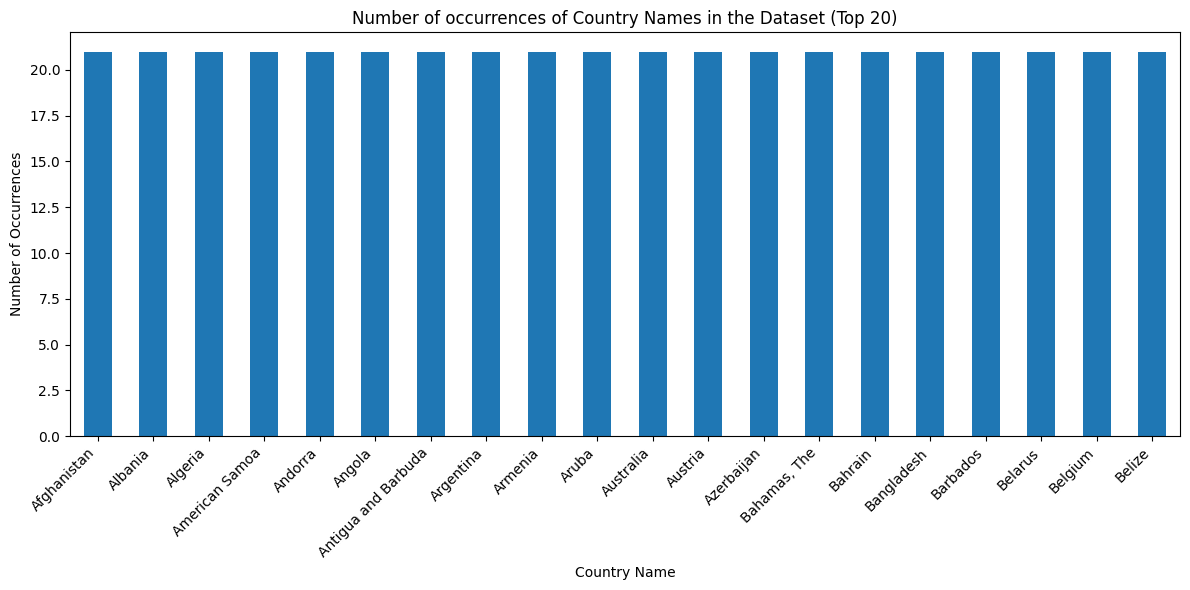

In [ ]:
import matplotlib.pyplot as plt

# Count the occurrences of each country_name
country_counts = df_cleaned['country_name'].value_counts()

# Plot the bar chart for the top countries (e.g., top 20)
plt.figure(figsize=(12, 6))
country_counts.head(20).plot(kind='bar')
plt.title('Number of occurrences of Country Names in the Dataset (Top 20)')
plt.xlabel('Country Name')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

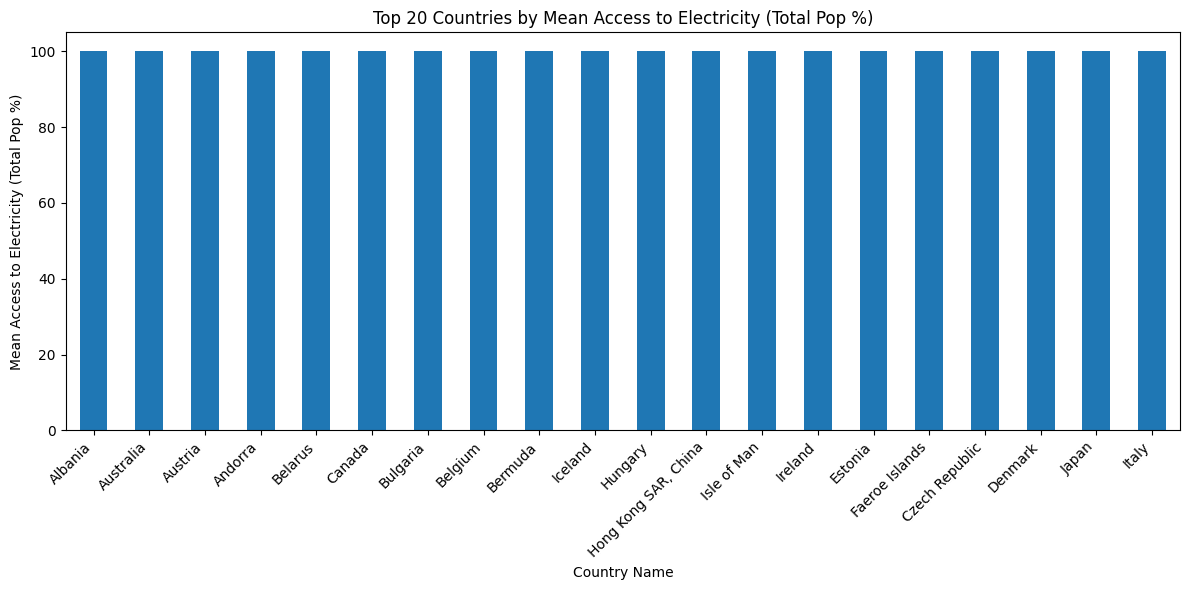

In [ ]:
import matplotlib.pyplot as plt

# Calculate the mean of 'access_electricity_total_pop_pct' for each country
country_access_electricity = df_cleaned.groupby('country_name')['access_electricity_total_pop_pct'].mean().sort_values(ascending=False)

# Select the top 20 countries
top_10_countries = country_access_electricity.head(20)

# Plot the bar chart
plt.figure(figsize=(12, 6))
top_10_countries.plot(kind='bar')
plt.title('Top 20 Countries by Mean Access to Electricity (Total Pop %)')
plt.xlabel('Country Name')
plt.ylabel('Mean Access to Electricity (Total Pop %)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

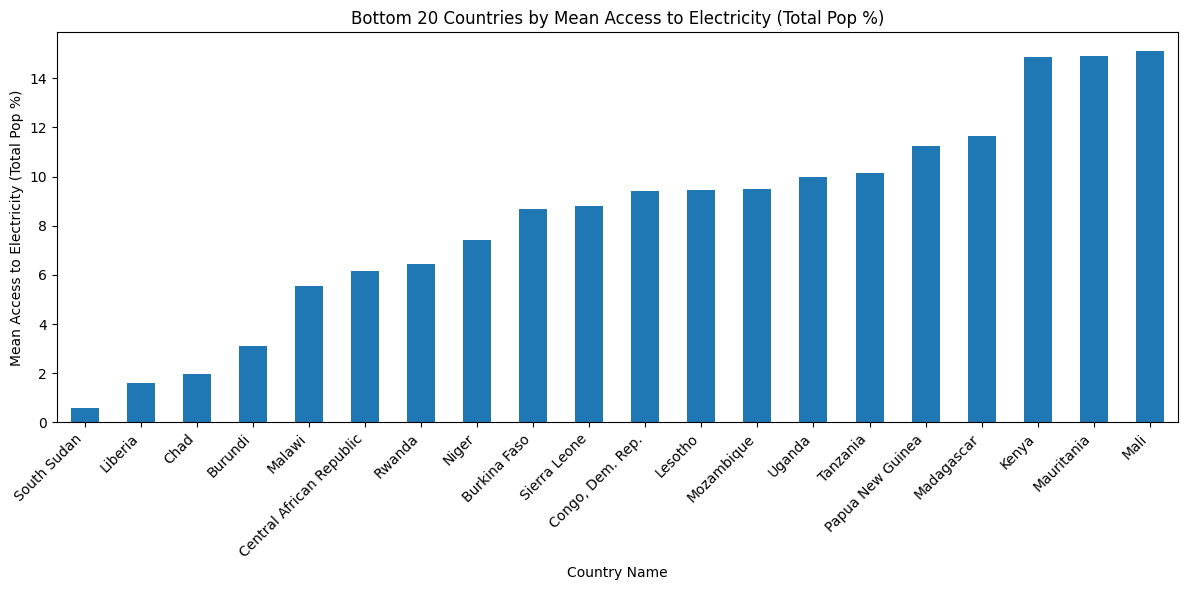

In [ ]:
# Prompt: generate a similar plot of the tail 20 countries

import matplotlib.pyplot as plt

# Calculate the mean of 'access_electricity_total_pop_pct' for each country
country_access_electricity = df_cleaned.groupby('country_name')['access_electricity_total_pop_pct'].mean().sort_values(ascending=True)

# Select the bottom 20 countries (tail 20)
bottom_20_countries = country_access_electricity.head(20)

# Plot the bar chart
plt.figure(figsize=(12, 6))
bottom_20_countries.plot(kind='bar')
plt.title('Bottom 20 Countries by Mean Access to Electricity (Total Pop %)')
plt.xlabel('Country Name')
plt.ylabel('Mean Access to Electricity (Total Pop %)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()